# CSDA STAC endpoint search

In [113]:
from urllib.parse import quote
import pandas as pd
import sys

sys.path.append('/projects/code/csda_summaries/lib')
import csdalib 

ModuleNotFoundError: No module named 'csdalib'

In [105]:
# Define your spreadsheet ID and sheet name
SPREADSHEET_ID = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'

In [114]:
SHEET_NAME = 'Evaluation Sites' # The name of the specific tab

# 2. Encode the sheet name for safe use in a URL
ENCODED_SHEET_NAME = quote(SHEET_NAME)

# 3. Construct the full URL using the gviz/tq endpoint
url = f"https://docs.google.com/spreadsheets/d/{SPREADSHEET_ID}/gviz/tq?tqx=out:csv&sheet={ENCODED_SHEET_NAME}"

# 4. Use pandas to read the CSV data directly from the URL
try:
    sites = pd.read_csv(url)
    sites['Site Name'] = sites['Site Name'].str.rstrip()
    #sites = sites[sites['Site Name'] != 'Sicily'] # Sicily site is same as Catania
    
except Exception as e:
    print(f"An error occurred: {e}")

sites_gdf = gpd.GeoDataFrame(
        sites,
        geometry=gpd.points_from_xy(sites['Longitude'], sites['Latitude']),
        crs="EPSG:4326"
    )
# # Buffer and drop empty geoms
# sites_gdf = csdalib.buffer_site_gdf(sites_gdf, BUF_KM)
# sites_gdf = sites_gdf[~sites_gdf.geometry.is_empty]

# Get the list of columns to drop
cols_to_drop = sites_gdf.columns[sites_gdf.columns.str.contains('Unnamed')]
sites_gdf = sites_gdf.drop(columns=cols_to_drop)

## List CSDA STAC Collections

In [37]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open('stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 16

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | N/A |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | N/A |
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-11-21 to 2024-05-31 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | N/A |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | N/A |
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2024-01-01 to 2025-07-31 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-01-01 to 2024-12-31 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2011-01-01 to Present |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | Blacksky | blacksky | N/A |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2003-01-01 to Present |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2010-01-01 to 2025-09-29 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-01 to 2024-12-31 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-01-01 to 2025-08-15 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-01-01 to 2025-08-13 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | Unknown to Present |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-01-02 to Present |



✓ Saved to stac_collections.md


In [38]:
def stac_items_to_gdf(items, properties_to_extract=None):
    """
    Convert STAC items to GeoDataFrame with optional property filtering
    
    Parameters:
    -----------
    items : list
        List of pystac.Item objects
    properties_to_extract : list, optional
        Specific properties to extract. If None, extracts all properties.
    """
    records = []
    
    for item in items:
        # Extract geometry
        geom = shape(item.geometry)
        
        # Base record
        record = {
            'id': item.id,
            'collection': item.collection_id,
            'datetime': item.datetime,
            'geometry': geom,
        }
        
        # Extract bbox
        if item.bbox:
            record['bbox'] = item.bbox
        
        # Extract specific or all properties
        if properties_to_extract:
            for prop in properties_to_extract:
                record[prop] = item.properties.get(prop)
        else:
            record.update(item.properties)
        
        # Add asset URLs (useful for downloading)
        for asset_key, asset in item.assets.items():
            record[f'asset_{asset_key}_href'] = asset.href
            record[f'asset_{asset_key}_type'] = asset.media_type
        
        records.append(record)
    
    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(records, crs='EPSG:4326')
    
    return gdf

## Create geodataframe of STAC records for a site

In [53]:
from pystac_client import Client
import geopandas as gpd
from shapely.geometry import shape
import matplotlib.pyplot as plt

# Open catalog and search
catalog = Client.open('https://csdap.earthdata.nasa.gov/stac')

In [84]:
RAILROAD_VALLEY_DICT = {'site': 'Railroad Valley', 'bbox': [-116.2, 38.2, -115.4, 38.8]}
# Libya-4 PICS site
LIBYA4_DICT = {'site': 'Libya-4', 'bbox': [23.3, 28.4, 23.5, 28.6]}  # [west, south, east, north]

In [86]:
SITE_DICT = LIBYA4_DICT

In [87]:
search = catalog.search(
    bbox=SITE_DICT['bbox'],
    datetime='2024-01-01/2024-12-31',
    collections=['planet', 'satellogic'],
    max_items=1000
)

In [115]:
def create_site_dict_from_gdf(sites_gdf, buffer_degrees=0.0001):
    """
    Create a dictionary of site names and bboxes from a sites GeoDataFrame
    
    Parameters:
    -----------
    sites_gdf : GeoDataFrame
        GeoDataFrame with 'Site_Name' column and point geometries
    buffer_degrees : float
        Buffer size in degrees around each point to create bbox (default 0.1)
    
    Returns:
    --------
    dict : Dictionary with site names as keys and bbox [west, south, east, north] as values
    """
    site_dict = {}
    
    for idx, row in sites_gdf.iterrows():
        site_name = row['Site_Name']
        geom = row['geometry']
        
        # Get point coordinates
        lon = geom.x
        lat = geom.y
        
        # Create bbox with buffer
        bbox = [
            lon - buffer_degrees,  # west
            lat - buffer_degrees,  # south
            lon + buffer_degrees,  # east
            lat + buffer_degrees   # north
        ]
        
        site_dict[site_name] = bbox
    
    return site_dict


# Use it
site_bboxes = create_site_dict_from_gdf(sites_gdf, buffer_degrees=0.1)

# See what you got
for site_name, bbox in site_bboxes.items():
    print(f"{site_name}: {bbox}")

# Use for searching
for site_name, bbox in site_bboxes.items():
    print(f"\nSearching {site_name}...")
    
    search = catalog.search(
        bbox=bbox,
        datetime='2024-06-01/2024-08-31',
        collections=['planet'],
        max_items=1000
    )
    
    items = list(search.items())
    print(f"  Found {len(items)} items")

KeyError: 'Site_Name'

Found 813 items

Shape: (813, 102)

Date range: 2024-02-06T11:59:07.559046Z to 2024-11-03T09:27:57.889501Z

Items by collection:
collection
planet        806
satellogic      7
Name: count, dtype: int64


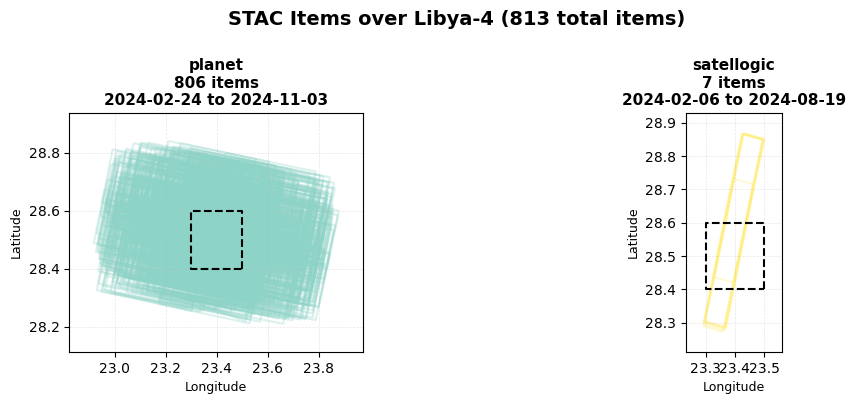

In [100]:
items = list(search.items())
print(f"Found {len(items)} items")

if len(items) > 0:
    # Convert to GeoDataFrame
    gdf = stac_items_to_gdf(items)
    
    # Explore the data
    print(f"\nShape: {gdf.shape}")
    
    # Summary statistics
    if 'datetime' in gdf.columns:
        print(f"\nDate range: {gdf['datetime'].min()} to {gdf['datetime'].max()}")
    
    if 'collection' in gdf.columns:
        collection_counts = gdf['collection'].value_counts()
        print(f"\nItems by collection:\n{collection_counts}")
        
        # Get unique collections
        collections = gdf['collection'].unique()
        n_collections = len(collections)
        
        # Create color palette
        colors = plt.cm.Set3(np.linspace(0, 1, n_collections))
        color_dict = dict(zip(collections, colors))
        
        # Determine subplot layout
        if n_collections == 1:
            ncols = 1
            nrows = 1
        elif n_collections == 2:
            ncols = 2
            nrows = 1
        elif n_collections <= 4:
            ncols = 2
            nrows = 2
        elif n_collections <= 6:
            ncols = 3
            nrows = 2
        else:
            ncols = 3
            nrows = (n_collections + 2) // 3
        
        # Create subplots
        fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
        
        # Flatten axes array
        if n_collections == 1:
            axes = [axes]
        else:
            axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
        
        # Create site bbox geometry
        site_bbox = SITE_DICT['bbox']  # [west, south, east, north]
        site_box = box(site_bbox[0], site_bbox[1], site_bbox[2], site_bbox[3])
        site_gdf = gpd.GeoDataFrame({'geometry': [site_box]}, crs='EPSG:4326')
        
        # Plot each collection
        for idx, collection in enumerate(collections):
            ax = axes[idx]
            
            # Filter by collection
            gdf_collection = gdf[gdf['collection'] == collection]
            
            # Plot footprints with consistent color
            gdf_collection.plot(
                ax=ax, 
                alpha=0.3, 
                edgecolor=color_dict[collection], 
                facecolor='none',
                linewidth=1.5
            )
            
            # Plot site bbox on top
            site_gdf.plot(
                ax=ax,
                facecolor='none',
                edgecolor='black',
                linewidth=1.5,
                linestyle='--',
                zorder=10
            )
            
            # Get date range for this collection
            date_info = ""
            if 'datetime' in gdf_collection.columns:
                dates = gdf_collection['datetime'].dropna()
                if len(dates) > 0:
                    try:
                        # Convert strings to datetime if needed
                        dates_converted = []
                        for d in dates:
                            if isinstance(d, str):
                                # Handle ISO format with Z
                                d_clean = d.replace('Z', '+00:00')
                                dates_converted.append(datetime.fromisoformat(d_clean))
                            else:
                                dates_converted.append(d)
                        
                        min_date = min(dates_converted)
                        max_date = max(dates_converted)
                        date_info = f"\n{min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}"
                    except Exception as e:
                        # Fallback: just use string slicing
                        min_date_str = str(min(dates))[:10]
                        max_date_str = str(max(dates))[:10]
                        date_info = f"\n{min_date_str} to {max_date_str}"
            
            # Title with collection name, count, and dates
            ax.set_title(f"{collection}\n{len(gdf_collection)} items{date_info}", 
                        fontsize=11, fontweight='bold')
            ax.set_xlabel('Longitude', fontsize=9)
            ax.set_ylabel('Latitude', fontsize=9)
            ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
            
            # Add bounding box with buffer
            minx, miny, maxx, maxy = gdf_collection.total_bounds
            buffer = max((maxx - minx), (maxy - miny)) * 0.1
            ax.set_xlim(minx - buffer, maxx + buffer)
            ax.set_ylim(miny - buffer, maxy + buffer)
        
        # Hide unused subplots
        for idx in range(n_collections, len(axes)):
            axes[idx].axis('off')
        
        # Overall title
        fig.suptitle(f"STAC Items over {SITE_DICT['site']} ({len(gdf)} total items)", 
                    fontsize=14, fontweight='bold', y=0.998)
        
        plt.tight_layout()
        plt.show()
    else:
        # Fallback if no collection column
        fig, ax = plt.subplots(figsize=(6, 4))
        gdf.plot(ax=ax, alpha=0.15, edgecolor='blue', facecolor='none')
        
        # Add site bbox
        site_bbox = SITE_DICT['bbox']
        site_box = box(site_bbox[0], site_bbox[1], site_bbox[2], site_bbox[3])
        site_gdf = gpd.GeoDataFrame({'geometry': [site_box]}, crs='EPSG:4326')
        site_gdf.plot(ax=ax, facecolor='none', edgecolor='black', 
                     linewidth=1.5, linestyle='--', zorder=10)
        
        ax.set_title(f'STAC Items over {SITE_DICT["site"]} ({len(gdf)} items)')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        plt.tight_layout()
        plt.show()

In [63]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np

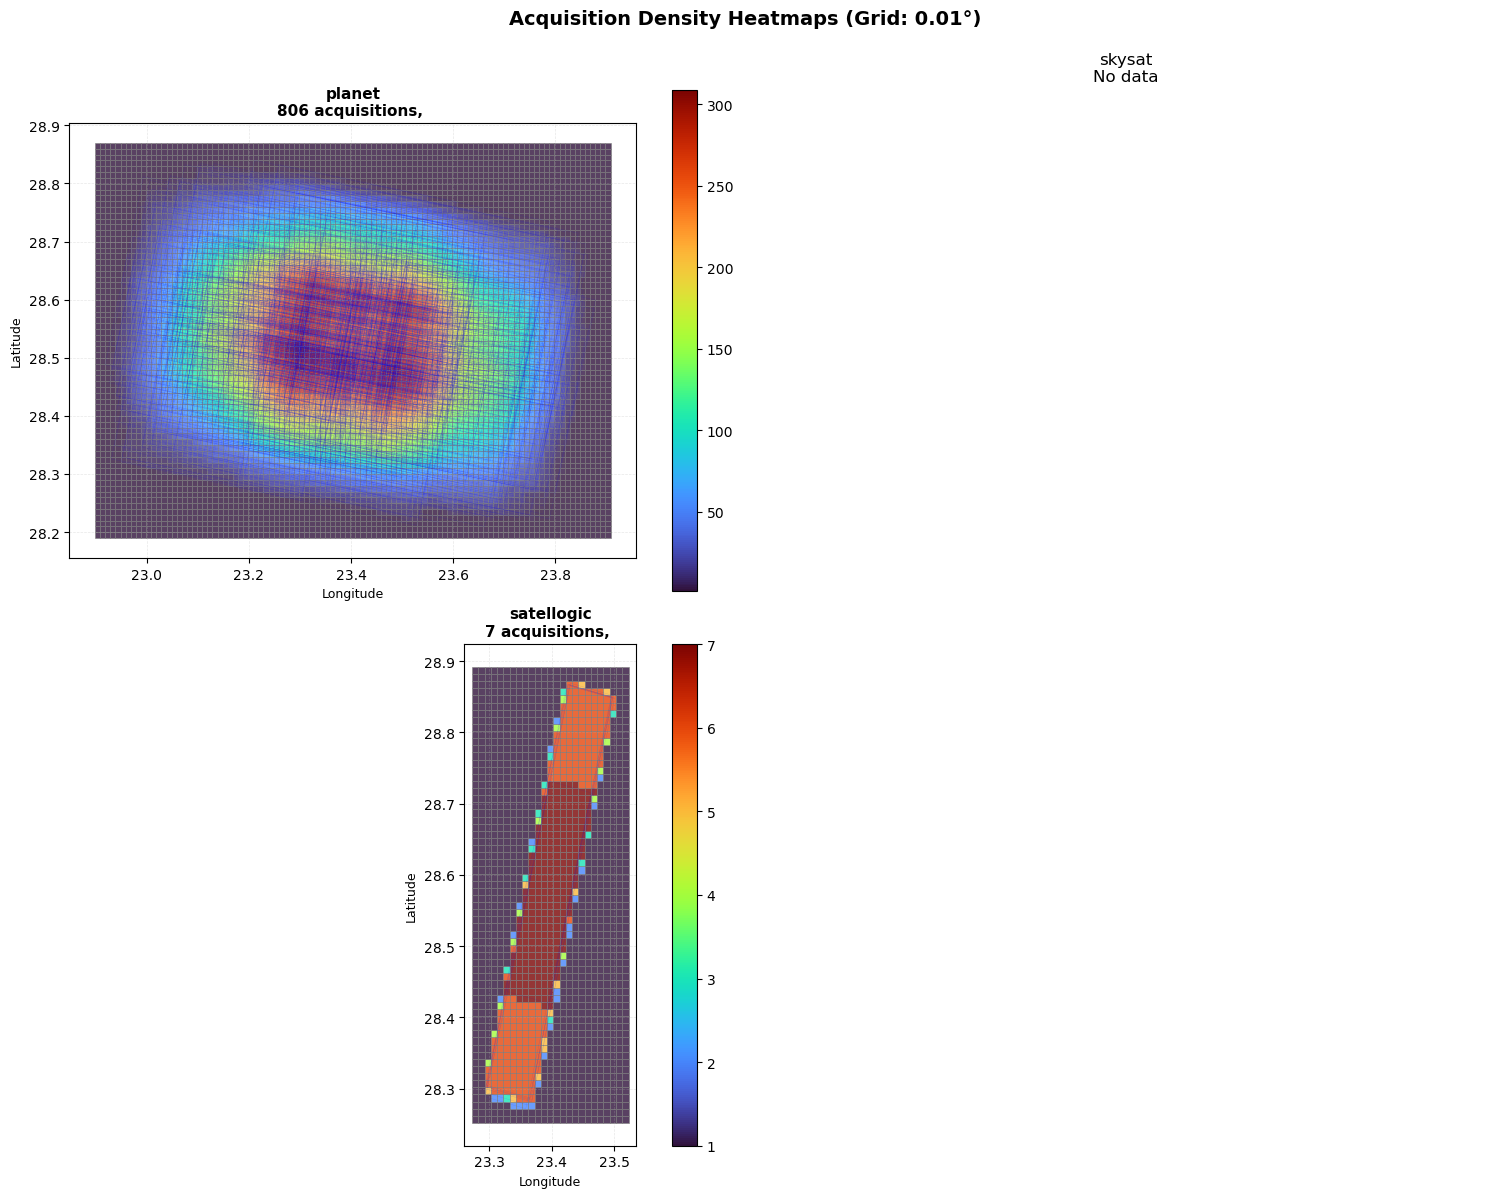

In [70]:
def create_acquisition_heatmap_multi(gdf, collections=None, grid_size=0.01, 
                                     cmap='turbo', figsize=(15, 12)):
    """
    Create multiple heatmaps comparing different collections
    """
    if collections is None:
        collections = gdf['collection'].unique()
    
    n_collections = len(collections)
    ncols = 2
    nrows = (n_collections + 1) // 2
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten() if n_collections > 1 else [axes]
    
    all_grids = {}
    
    for idx, collection in enumerate(collections):
        ax = axes[idx]
        
        # Filter data
        gdf_filtered = gdf[gdf['collection'] == collection].copy()
        
        if len(gdf_filtered) == 0:
            ax.set_title(f'{collection}\nNo data')
            ax.axis('off')
            continue
        
        # Get bounds
        minx, miny, maxx, maxy = gdf_filtered.total_bounds
        buffer = grid_size * 2
        minx -= buffer
        miny -= buffer
        maxx += buffer
        maxy += buffer
        
        # Create grid
        x_coords = np.arange(minx, maxx, grid_size)
        y_coords = np.arange(miny, maxy, grid_size)
        
        grid_cells = []
        for x in x_coords:
            for y in y_coords:
                cell = box(x, y, x + grid_size, y + grid_size)
                grid_cells.append(cell)
        
        grid_gdf = gpd.GeoDataFrame({'geometry': grid_cells}, crs=gdf_filtered.crs)
        
        # Count acquisitions
        joined = gpd.sjoin(grid_gdf, gdf_filtered, how='left', predicate='intersects')
        counts = joined.groupby(joined.index).size()
        grid_gdf['count'] = 0
        grid_gdf.loc[counts.index, 'count'] = counts.values
        grid_gdf_filtered = grid_gdf[grid_gdf['count'] > 0].copy()
        
        all_grids[collection] = grid_gdf_filtered
        
        # Plot
        grid_gdf_filtered.plot(
            column='count',
            cmap=cmap,
            legend=True,
            ax=ax,
            edgecolor='gray',
            linewidth=0.5,
            alpha=0.8
        )
        
        gdf_filtered.plot(
            ax=ax,
            facecolor='none',
            edgecolor='blue',
            linewidth=0.2,
            alpha=0.2
        )
        
        ax.set_title(f'{collection}\n{len(gdf_filtered)} acquisitions, '
                    #f'{len(grid_gdf_filtered)} grid cells'
                    ,fontsize=11, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=9)
        ax.set_ylabel('Latitude', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Hide unused subplots
    for idx in range(n_collections, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Acquisition Density Heatmaps (Grid: {grid_size}°)', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    return all_grids, fig


# Use it
all_grids, fig = create_acquisition_heatmap_multi(
    gdf,
    collections=['planet', 'skysat', 'satellogic'],
    grid_size=0.01
)
plt.show()

In [102]:
def create_interactive_heatmap(gdf, collection_name=None, grid_size=0.1, 
                               cmap='turbo', site_name='Libya-4'):
    """
    Create interactive heatmap with folium as a single named layer
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        Acquisition footprints
    collection_name : str, optional
        Collection to filter by
    grid_size : float
        Grid cell size in degrees
    cmap : str
        Matplotlib colormap name
    site_name : str
        Name of the site for the legend
    """
    # Filter by collection
    if collection_name:
        gdf_filtered = gdf[gdf['collection'] == collection_name].copy()
        collection_label = collection_name.title()
    else:
        gdf_filtered = gdf.copy()
        collection_label = "All Collections"
    
    print(f"Creating heatmap for {len(gdf_filtered)} acquisitions")
    
    # Create grid
    minx, miny, maxx, maxy = gdf_filtered.total_bounds
    buffer = grid_size * 2
    minx -= buffer
    miny -= buffer
    maxx += buffer
    maxy += buffer
    
    x_coords = np.arange(minx, maxx, grid_size)
    y_coords = np.arange(miny, maxy, grid_size)
    
    grid_cells = []
    for x in x_coords:
        for y in y_coords:
            cell = box(x, y, x + grid_size, y + grid_size)
            grid_cells.append(cell)
    
    grid_gdf = gpd.GeoDataFrame({'geometry': grid_cells}, crs=gdf_filtered.crs)
    
    # Count acquisitions
    joined = gpd.sjoin(grid_gdf, gdf_filtered, how='left', predicate='intersects')
    counts = joined.groupby(joined.index).size()
    grid_gdf['count'] = 0
    grid_gdf.loc[counts.index, 'count'] = counts.values
    grid_gdf = grid_gdf[grid_gdf['count'] > 0].copy()
    
    print(f"Grid cells with data: {len(grid_gdf)}")
    print(f"Acquisition count range: {grid_gdf['count'].min()} - {grid_gdf['count'].max()}")
    
    # Get date range
    date_str = "unknown_dates"
    if 'datetime' in gdf_filtered.columns:
        dates = gdf_filtered['datetime'].dropna()
        if len(dates) > 0:
            try:
                # Handle different datetime formats
                dates_converted = []
                for d in dates:
                    if isinstance(d, str):
                        dates_converted.append(datetime.fromisoformat(d.replace('Z', '+00:00')))
                    else:
                        dates_converted.append(d)
                
                start_date = min(dates_converted)
                end_date = max(dates_converted)
                date_str = f"{start_date.strftime('%Y%m%d')}-{end_date.strftime('%Y%m%d')}"
            except Exception as e:
                print(f"Could not parse dates: {e}")
    
    # Create layer name
    layer_name = f"{site_name} {collection_label} {date_str}"
    
    # Create map
    center_lat = (miny + maxy) / 2
    center_lon = (minx + maxx) / 2
    m = folium.Map(location=[center_lat, center_lon], zoom_start=10)
    
    # Get matplotlib colormap and convert to hex colors
    min_count = grid_gdf['count'].min()
    max_count = grid_gdf['count'].max()
    
    mpl_cmap = plt.get_cmap(cmap)
    n_colors = 256
    colors = [mcolors.rgb2hex(mpl_cmap(i / n_colors)) for i in range(n_colors)]
    
    # Create branca colormap
    colormap = cm.LinearColormap(
        colors=colors,
        vmin=min_count,
        vmax=max_count,
        caption=f'Acquisitions per {grid_size}° cell'
    )
    
    # Create style function
    def style_function(feature):
        count = feature['properties']['count']
        color = colormap(count)
        return {
            'fillColor': color,
            'color': 'gray',
            'weight': 0.5,
            'fillOpacity': 0.7
        }
    
    # Add single GeoJson layer
    folium.GeoJson(
        grid_gdf,
        name=layer_name,
        style_function=style_function,
        tooltip=folium.GeoJsonTooltip(
            fields=['count'],
            aliases=['Acquisitions:'],
            localize=True,
            sticky=False,
            labels=True,
            style="""
                background-color: #F0EFEF;
                border: 2px solid black;
                border-radius: 3px;
                box-shadow: 3px;
            """,
        )
    ).add_to(m)
    
    # Add colormap legend
    colormap.add_to(m)
    
    # Add layer control
    folium.LayerControl().add_to(m)
    
    # Add title
    title_html = f'''
        <div style="position: fixed; 
                    top: 10px; left: 50px; width: 400px; height: 50px; 
                    background-color: white; border:2px solid grey; z-index:9999; 
                    font-size:14px; padding: 10px">
        <b>{layer_name}</b><br>
        Total acquisitions: {len(gdf_filtered)} | Grid cells: {len(grid_gdf)}
        </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    return m, grid_gdf


# Use it
m, grid_gdf = create_interactive_heatmap(
    gdf,
    collection_name='satellogic',
    grid_size=0.01,
    cmap='turbo',
    site_name='Libya-4'
)

m.save('libya4_satellogic_heatmap.html')
m

Creating heatmap for 7 acquisitions
Grid cells with data: 1600
Acquisition count range: 1 - 7
